In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix)

# Create output directories
os.makedirs("../Models/Best_Model", exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [27]:
# Note: Splits are stored as X_train.csv, y_train.csv, X_test.csv, y_test.csv
X_train = pd.read_csv("../Data/Splits/X_train.csv")
y_train = pd.read_csv("../Data/Splits/y_train.csv").squeeze().values
X_test  = pd.read_csv("../Data/Splits/X_test.csv")
y_test  = pd.read_csv("../Data/Splits/y_test.csv").squeeze().values

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class distribution:", pd.Series(y_train).value_counts().to_dict())
print("Test class distribution:", pd.Series(y_test).value_counts().to_dict())

Train shape: (12800, 8)
Test shape: (2001, 8)
Train class distribution: {1: 6400, 0: 6400}
Test class distribution: {0: 1600, 1: 401}


In [28]:
def get_classification_metrics(model, X_train, y_train, X_test, y_test):
    """Returns dict with train/test metrics: accuracy, precision, recall, f1, roc_auc"""
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # ROC AUC requires predict_proba (skip if not available)
    if hasattr(model, "predict_proba"):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_proba = model.predict_proba(X_test)[:, 1]
        train_auc = roc_auc_score(y_train, y_train_proba)
        test_auc = roc_auc_score(y_test, y_test_proba)
    else:
        train_auc = test_auc = np.nan

    metrics = {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train Precision": precision_score(y_train, y_train_pred),
        "Test Precision": precision_score(y_test, y_test_pred),
        "Train Recall": recall_score(y_train, y_train_pred),
        "Test Recall": recall_score(y_test, y_test_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Test F1": f1_score(y_test, y_test_pred),
        "Train ROC AUC": train_auc,
        "Test ROC AUC": test_auc,
    }
    return metrics, y_test_pred, y_test_proba if hasattr(model, "predict_proba") else None

In [29]:
base_path = "../Models/Baseline_Models/"
tuned_path = "../Models/Tuned_Models/"

# Classification models saved earlier
models_to_load = {
    "Logistic Regression (Base)": base_path + "Logistic_Regression.pkl",
    "Decision Tree (Base)": base_path + "Decision_Tree.pkl",
    "Random Forest (Base)": base_path + "Random_Forest.pkl",
    "XGBoost (Base)": base_path + "XGBoost.pkl",
    "K-Nearest Neighbours (Base)": base_path + "K-Nearest_Neighbours.pkl",
    "XGBoost (Tuned)": tuned_path + "xgboost_tuned.pkl",   # from tuning notebook
}

loaded_models = {}
all_metrics = {}
predictions = {}      # store test predictions
probabilities = {}    # store test probabilities (for ROC)

for name, path in models_to_load.items():
    try:
        model = joblib.load(path)
        loaded_models[name] = model
        metrics, y_pred, y_proba = get_classification_metrics(model, X_train, y_train, X_test, y_test)
        all_metrics[name] = metrics
        predictions[name] = y_pred
        probabilities[name] = y_proba
        print(f"✓ Loaded {name}")
    except Exception as e:
        print(f"✗ Failed to load {name}: {e}")

✓ Loaded Logistic Regression (Base)
✓ Loaded Decision Tree (Base)
✓ Loaded Random Forest (Base)
✓ Loaded XGBoost (Base)
✓ Loaded K-Nearest Neighbours (Base)
✓ Loaded XGBoost (Tuned)


In [30]:
# Extract only test metrics for comparison (plus train F1 for overfitting)
test_metrics = ["Test Accuracy", "Test Precision", "Test Recall", "Test F1", "Test ROC AUC"]
train_f1 = ["Train F1"]

comparison_df = pd.DataFrame(all_metrics).T[test_metrics + train_f1].copy()
comparison_df = comparison_df.round(4)

print("\n=== CLASSIFICATION MODEL COMPARISON (Test Set) ===")
print(comparison_df.to_string())


=== CLASSIFICATION MODEL COMPARISON (Test Set) ===
                             Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC AUC  Train F1
Logistic Regression (Base)          0.8001          0.5007       0.9476   0.6552        0.9332    0.8695
Decision Tree (Base)                0.9765          0.9194       0.9676   0.9429        0.9732    1.0000
Random Forest (Base)                0.9790          0.9165       0.9850   0.9495        0.9954    1.0000
XGBoost (Base)                      0.9800          0.9207       0.9850   0.9518        0.9972    0.9978
K-Nearest Neighbours (Base)         0.9395          0.7941       0.9426   0.8620        0.9799    0.9752
XGBoost (Tuned)                     0.9810          0.9153       0.9975   0.9547        0.9971    0.9893


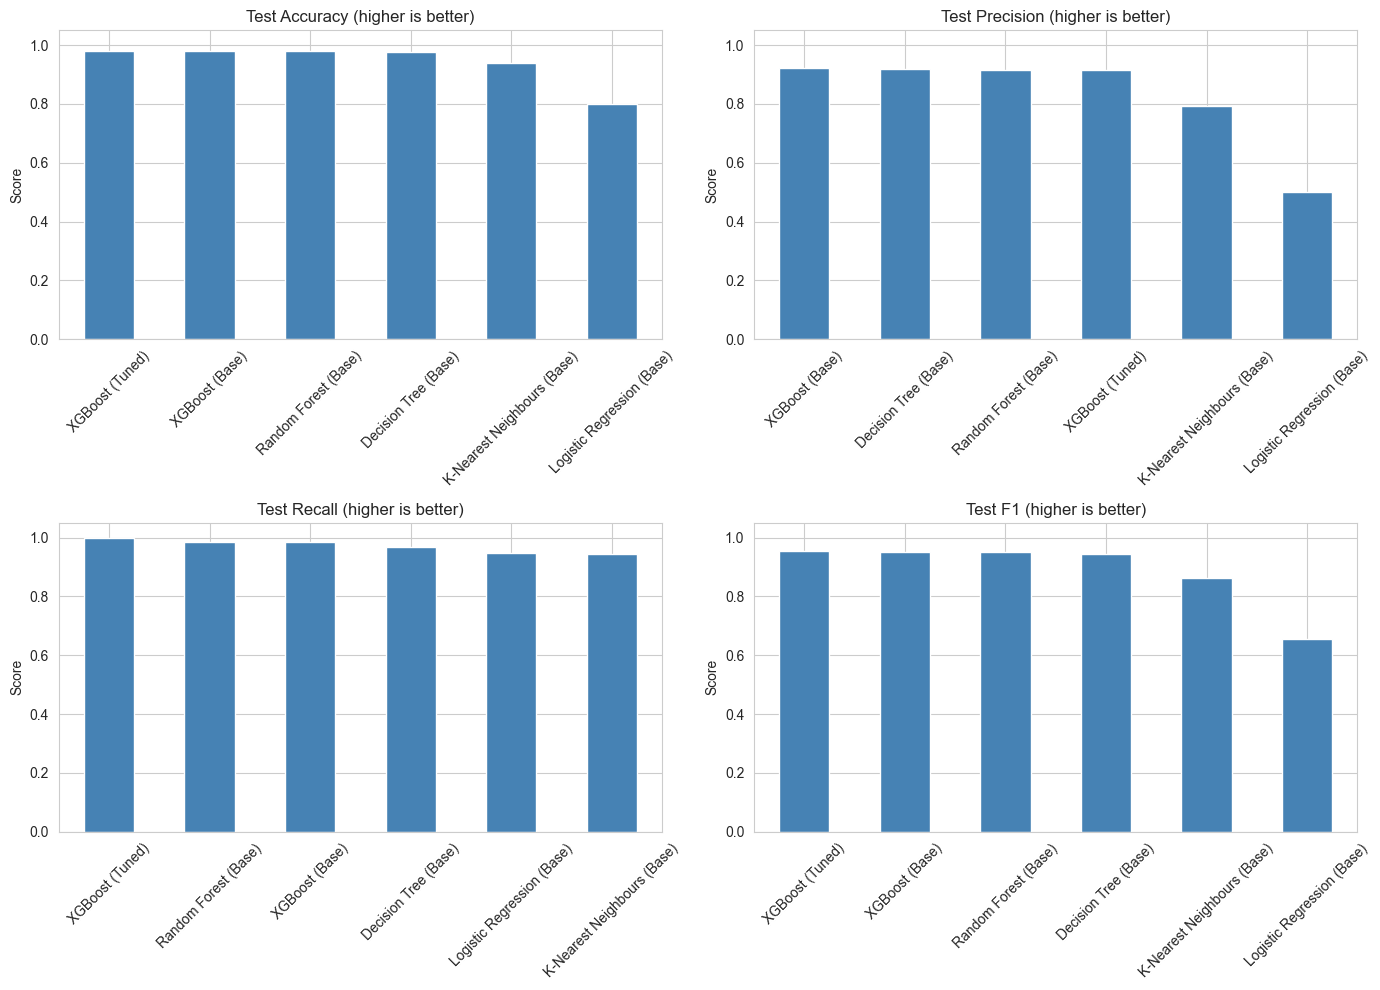

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics_to_plot = ["Test Accuracy", "Test Precision", "Test Recall", "Test F1"]
for idx, metric in enumerate(metrics_to_plot):
    sorted_df = comparison_df.sort_values(metric, ascending=False)
    sorted_df[metric].plot(kind="bar", ax=axes[idx], color="steelblue")
    axes[idx].set_title(f"{metric} (higher is better)")
    axes[idx].set_ylabel("Score")
    axes[idx].set_ylim(0, 1.05)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

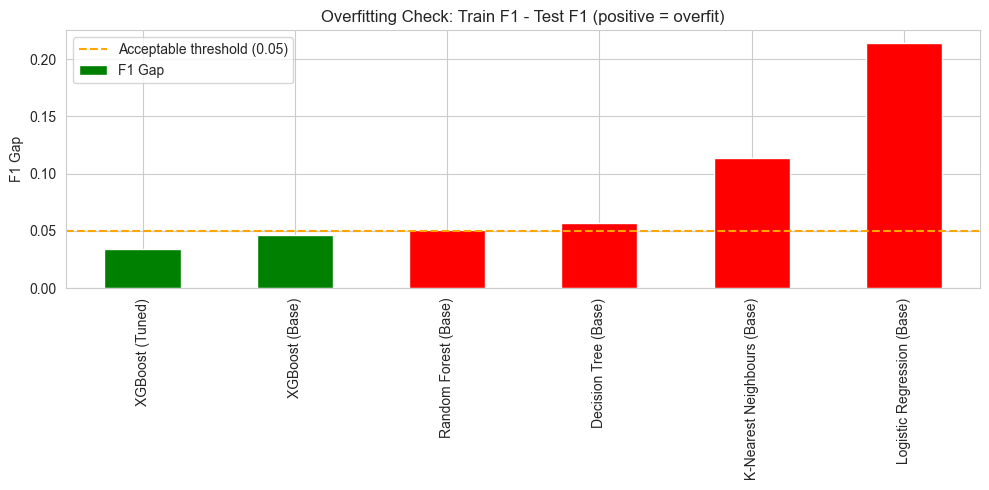


Overfitting gaps (Train F1 - Test F1):
  Logistic Regression (Base)     : gap = 0.2143 → ⚠️ Overfitting
  Decision Tree (Base)           : gap = 0.0571 → ⚠️ Overfitting
  Random Forest (Base)           : gap = 0.0505 → ⚠️ Overfitting
  XGBoost (Base)                 : gap = 0.0460 → ✅ Generalises well
  K-Nearest Neighbours (Base)    : gap = 0.1132 → ⚠️ Overfitting
  XGBoost (Tuned)                : gap = 0.0346 → ✅ Generalises well


In [32]:
comparison_df["F1 Gap"] = comparison_df["Train F1"] - comparison_df["Test F1"]

# Plot overfitting gaps
gap_sorted = comparison_df["F1 Gap"].sort_values()
colors = ["red" if g > 0.05 else "green" for g in gap_sorted]
gap_sorted.plot(kind="bar", color=colors, figsize=(10,5))
plt.axhline(y=0.05, color="orange", linestyle="--", label="Acceptable threshold (0.05)")
plt.title("Overfitting Check: Train F1 - Test F1 (positive = overfit)")
plt.ylabel("F1 Gap")
plt.legend()
plt.tight_layout()
plt.show()

print("\nOverfitting gaps (Train F1 - Test F1):")
for name in comparison_df.index:
    gap = comparison_df.loc[name, "F1 Gap"]
    status = "⚠️ Overfitting" if gap > 0.05 else "✅ Generalises well"
    print(f"  {name:30s} : gap = {gap:.4f} → {status}")

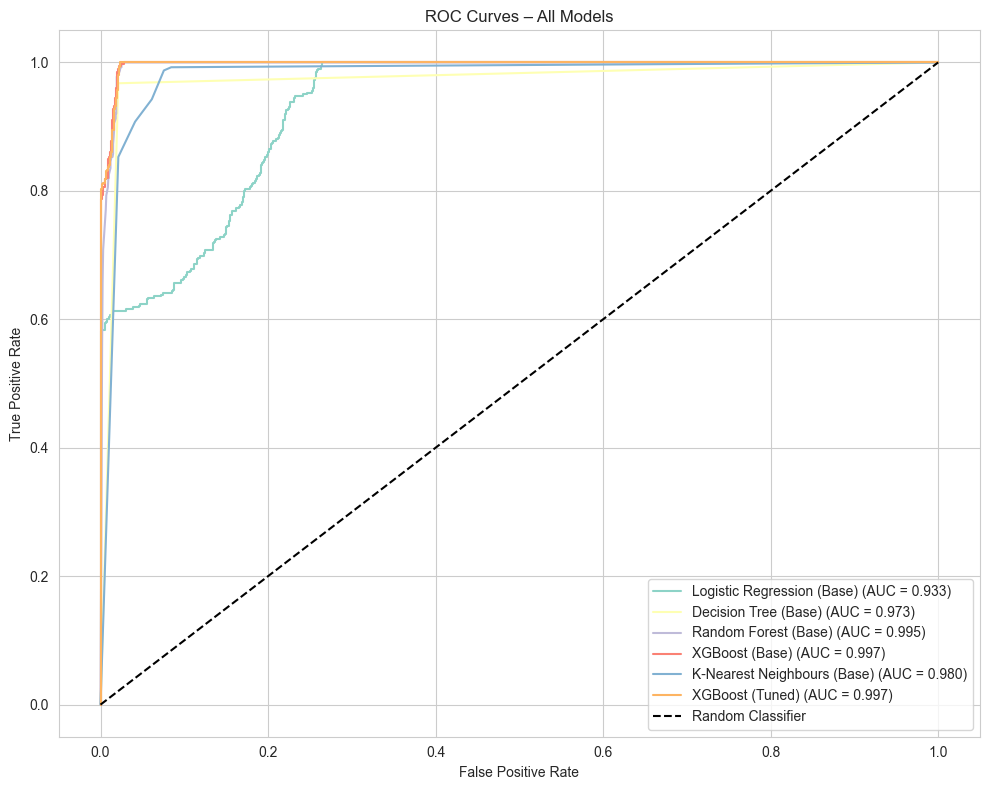

In [33]:
plt.figure(figsize=(10, 8))
for name, proba in probabilities.items():
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = all_metrics[name]["Test ROC AUC"]
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

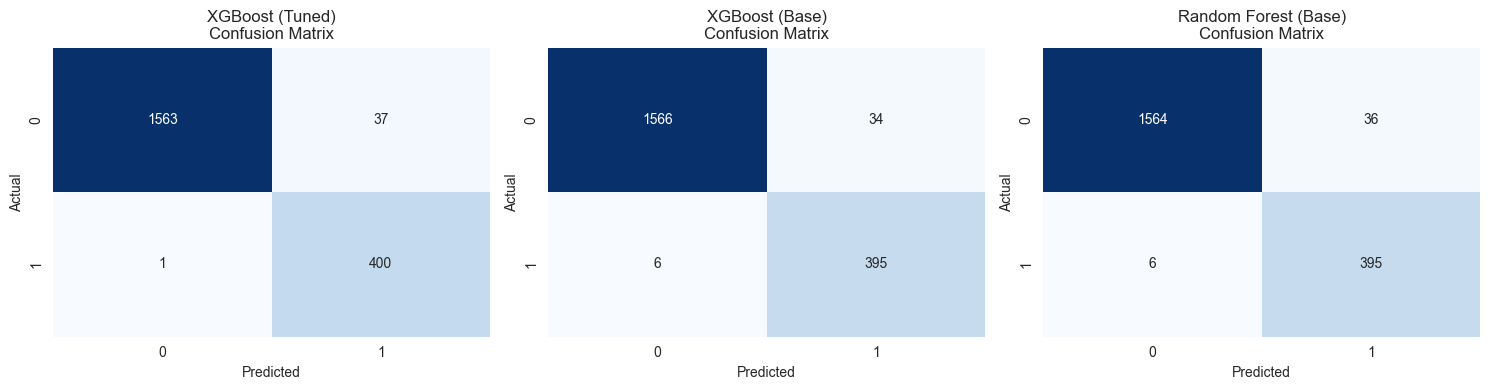

In [34]:
# Get top 3 models by Test F1 (excluding any with NaN F1)
top_3_names = comparison_df.dropna(subset=["Test F1"]).sort_values("Test F1", ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, len(top_3_names), figsize=(5*len(top_3_names), 4))
if len(top_3_names) == 1:
    axes = [axes]

for i, name in enumerate(top_3_names):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i], cbar=False)
    axes[i].set_title(f"{name}\nConfusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [35]:
# Define trust criteria: F1 gap <= 0.05 and Test F1 not NaN
trustworthy = comparison_df[
    (comparison_df["F1 Gap"] <= 0.05) &
    (comparison_df["Test F1"].notna())
].copy()

if trustworthy.empty:
    # Fallback: use highest Test F1
    best_model_name = comparison_df["Test F1"].idxmax()
    print(f"\n⚠️ Warning: No model passed trust threshold. Using overall best Test F1: {best_model_name}")
else:
    # Among trustworthy, pick highest Test F1
    best_model_name = trustworthy.sort_values("Test F1", ascending=False).index[0]

best_model = loaded_models[best_model_name]
best_model_path = f"../Models/Best_Model/Best_{best_model_name.replace(' ', '_')}.pkl"
joblib.dump(best_model, best_model_path)

print(f"\n🏆 Best model saved to: {best_model_path}")
print(f"   Test F1 = {all_metrics[best_model_name]['Test F1']:.4f}")
print(f"   Test ROC AUC = {all_metrics[best_model_name]['Test ROC AUC']:.4f}")
print(f"   Test Accuracy = {all_metrics[best_model_name]['Test Accuracy']:.4f}")


🏆 Best model saved to: ../Models/Best_Model/Best_XGBoost_(Tuned).pkl
   Test F1 = 0.9547
   Test ROC AUC = 0.9971
   Test Accuracy = 0.9810


In [36]:
print("\n=== IMPROVEMENT FROM BASELINE TO TUNED ===")
if "XGBoost (Base)" in all_metrics and "XGBoost (Tuned)" in all_metrics:
    base_f1 = all_metrics["XGBoost (Base)"]["Test F1"]
    tuned_f1 = all_metrics["XGBoost (Tuned)"]["Test F1"]
    base_auc = all_metrics["XGBoost (Base)"]["Test ROC AUC"]
    tuned_auc = all_metrics["XGBoost (Tuned)"]["Test ROC AUC"]
    print(f"F1 Score:     {base_f1:.4f} → {tuned_f1:.4f}  ({'+' if tuned_f1>base_f1 else ''}{tuned_f1-base_f1:.4f})")
    print(f"ROC AUC:      {base_auc:.4f} → {tuned_auc:.4f}  ({'+' if tuned_auc>base_auc else ''}{tuned_auc-base_auc:.4f})")
else:
    print("XGBoost baseline or tuned not found for comparison.")


=== IMPROVEMENT FROM BASELINE TO TUNED ===
F1 Score:     0.9518 → 0.9547  (+0.0028)
ROC AUC:      0.9972 → 0.9971  (-0.0001)


In [37]:
import numpy as np

ranking_df = comparison_df[["Test F1", "Test ROC AUC", "Test Accuracy", "F1 Gap"]].copy()
ranking_df = ranking_df.sort_values("Test F1", ascending=False)

# Create trustworthy mask directly from comparison_df (same index as ranking_df)
trustworthy_mask = (comparison_df["F1 Gap"] <= 0.05) & (comparison_df["Test F1"].notna())

# Align mask to ranking_df index and assign labels
ranking_df["Trustworthy?"] = np.where(trustworthy_mask.loc[ranking_df.index], "✅ Yes", "❌ No")

print("\n=== FINAL MODEL RANKING (by Test F1) ===")
print(ranking_df.round(4))


=== FINAL MODEL RANKING (by Test F1) ===
                             Test F1  Test ROC AUC  Test Accuracy  F1 Gap  \
XGBoost (Tuned)               0.9547        0.9971         0.9810  0.0346   
XGBoost (Base)                0.9518        0.9972         0.9800  0.0460   
Random Forest (Base)          0.9495        0.9954         0.9790  0.0505   
Decision Tree (Base)          0.9429        0.9732         0.9765  0.0571   
K-Nearest Neighbours (Base)   0.8620        0.9799         0.9395  0.1132   
Logistic Regression (Base)    0.6552        0.9332         0.8001  0.2143   

                            Trustworthy?  
XGBoost (Tuned)                    ✅ Yes  
XGBoost (Base)                     ✅ Yes  
Random Forest (Base)                ❌ No  
Decision Tree (Base)                ❌ No  
K-Nearest Neighbours (Base)         ❌ No  
Logistic Regression (Base)          ❌ No  
